This notebook evaluates whether **correct image-caption pairing** matters for the attention-fusion model under matched robustness seeds.

Conditions evaluated:
- `real`: each image uses its original caption
- `shuffled`: captions are randomly reassigned within each split
- `class_randomized`: captions are reassigned from a different style class within each split

Key design choices used in these experiments:
- caption assignments are built **after splitting** and **within each split separately** to avoid train/val/test leakage
- the fusion architecture, image splits, seeds, optimizer, and metrics are kept fixed; only the caption assignment changes

This notebook was used to:
1. run one-seed smoke tests for each caption condition
2. run a 5-seed pilot comparison
3. run all 30 matched seeds for the final caption-sanity control

In [1]:
from pathlib import Path
from urllib.parse import unquote
import json
import os
import random
import time
import warnings

import clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from IPython.display import display
from scipy import stats
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

_walk = Path.cwd().resolve()
for _ in range(10):
    if (_walk / "experiments").is_dir() and (_walk / "data").is_dir():
        PROJECT_ROOT = _walk
        break
    _walk = _walk.parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

BASE_DIR = PROJECT_ROOT
DATASET_CSV = PROJECT_ROOT / "data" / "processed" / "caption_dataset_final_full.csv"
SPLITS_ROOT = PROJECT_ROOT / "data" / "splits"
SEEDS_FILE = PROJECT_ROOT / "experiments" / "phase3_robustness" / "metrics" / "seeds_list.txt"

# Select one condition at a time: "real", "shuffled", or "class_randomized"
CAPTION_CONDITION = "real"

EXPERIMENT_ROOT = PROJECT_ROOT / "experiments" / f"caption_sanity_{CAPTION_CONDITION}"
METRICS_DIR = EXPERIMENT_ROOT / "metrics"
ARTIFACTS_DIR = EXPERIMENT_ROOT / "artifacts"
(METRICS_DIR / "experiments").mkdir(parents=True, exist_ok=True)
(ARTIFACTS_DIR / "models").mkdir(parents=True, exist_ok=True)
(ARTIFACTS_DIR / "learning_curves").mkdir(parents=True, exist_ok=True)
(ARTIFACTS_DIR / "assignment_audits").mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_INIT_SEED = 42
DEBUG_SAMPLES = 5
NUM_WORKERS = 2
LEARNING_RATE = 5e-5
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 20
ONLY_SEEDS = []  # e.g. [13] for a smoke test; leave [] for full 30 seeds

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_CSV:", DATASET_CSV)
print("SPLITS_ROOT:", SPLITS_ROOT)
print("SEEDS_FILE:", SEEDS_FILE)
print("CAPTION_CONDITION:", CAPTION_CONDITION)
print("EXPERIMENT_ROOT:", EXPERIMENT_ROOT)
print("DEVICE:", DEVICE)

/home/ding-zhang/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/ding-zhang/Dongmei/DATA255/Project
DATASET_CSV: /home/ding-zhang/Dongmei/DATA255/Project/data/processed/caption_dataset_final_full.csv
SPLITS_ROOT: /home/ding-zhang/Dongmei/DATA255/Project/data/splits
SEEDS_FILE: /home/ding-zhang/Dongmei/DATA255/Project/experiments/phase3_robustness/metrics/seeds_list.txt
CAPTION_CONDITION: real
EXPERIMENT_ROOT: /home/ding-zhang/Dongmei/DATA255/Project/experiments/caption_sanity_real
DEVICE: cuda


## 1. Load Dataset And Base Models

This section loads the shared resources used across all caption-sanity conditions:
- the caption dataset and style metadata
- the fixed 30-seed list used by the robustness experiments
- the frozen CLIP image encoder and BERT text encoder used by the attention-fusion model

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_seed_worker(base_seed):
    def seed_worker(worker_id):
        worker_seed = base_seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    return seed_worker

    
def load_phase3_seeds(seeds_file):
    text = Path(seeds_file).read_text(encoding="utf-8")
    import re
    seeds = [int(x) for x in re.findall(r"Seed\s+(\d+)", text)]
    if not seeds:
        raise RuntimeError(f"No seeds found in {seeds_file}")
    return seeds


def load_style_metadata(dataset_csv):
    df = pd.read_csv(dataset_csv)
    df = df[df["status"] == "success"].copy()
    df["style"] = df["style"].str.strip()
    all_styles = sorted(df["style"].unique())
    style_to_idx = {style: idx for idx, style in enumerate(all_styles)}
    idx_to_style = {idx: style for style, idx in style_to_idx.items()}
    return df, all_styles, style_to_idx, idx_to_style


def load_split_csvs(seed):
    split_dir = SPLITS_ROOT / f"seed_{seed}"
    train_df = pd.read_csv(split_dir / "train.csv")
    val_df = pd.read_csv(split_dir / "val.csv")
    test_df = pd.read_csv(split_dir / "test.csv")
    return split_dir, train_df, val_df, test_df


def resolve_image_path(image_path, base_dir):
    image_path = str(image_path)
    if not os.path.isabs(image_path):
        rel_path = image_path.replace("\\", "/")
        dataset_root = base_dir / "dataset"
        if rel_path.startswith("dataset/") and not dataset_root.is_dir():
            image_path = str(base_dir / "data" / "raw dataset" / rel_path[len("dataset/"):])
        else:
            image_path = str(base_dir / image_path)

    if "%" in image_path:
        parts = image_path.split("/")
        image_path = "/".join(unquote(part) if "%" in part else part for part in parts)

    return os.path.normpath(image_path)


def debug_path_resolution(df, sample_count=DEBUG_SAMPLES):
    print("=== Path resolution sanity check ===")
    print("BASE_DIR:", BASE_DIR)
    print("Top-level dataset/ exists:", (BASE_DIR / "dataset").is_dir())
    print("data/raw dataset/ exists:", (BASE_DIR / "data" / "raw dataset").is_dir())

    sample_count = min(sample_count, len(df))
    resolved_found = 0
    for raw_path in df["image_path"].head(sample_count):
        resolved_path = resolve_image_path(raw_path, BASE_DIR)
        exists = os.path.exists(resolved_path)
        resolved_found += int(exists)
        print(f"  exists={exists} raw={raw_path}")
        print(f"         resolved={resolved_path}")
    print(f"Resolved files found: {resolved_found}/{sample_count}")


df_full, all_styles, style_to_idx, idx_to_style = load_style_metadata(DATASET_CSV)
SEEDS = ONLY_SEEDS if ONLY_SEEDS else load_phase3_seeds(SEEDS_FILE)

print(f"Loaded caption dataset: {len(df_full)} successful samples")
print(f"Styles ({len(all_styles)}):", all_styles)
print(f"Seeds ({len(SEEDS)}):", SEEDS)

sample_split_dir, sample_train_df, sample_val_df, sample_test_df = load_split_csvs(SEEDS[0])
print("Sample split dir:", sample_split_dir)
print("Sample split sizes:", len(sample_train_df), len(sample_val_df), len(sample_test_df))
debug_path_resolution(sample_train_df)

print("Loading CLIP model...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_model = clip_model.float()
clip_model.eval()
print("CLIP model loaded!")

print("Loading FashionBERT...")
fashionbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
fashionbert_model = AutoModel.from_pretrained("bert-base-uncased").to(DEVICE)
fashionbert_model.eval()
print("FashionBERT model loaded!")

Loaded caption dataset: 13230 successful samples
Styles (14): ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Seeds (30): [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]
Sample split dir: /home/ding-zhang/Dongmei/DATA255/Project/data/splits/seed_13
Sample split sizes: 9261 1984 1985
=== Path resolution sanity check ===
BASE_DIR: /home/ding-zhang/Dongmei/DATA255/Project
Top-level dataset/ exists: False
data/raw dataset/ exists: True
  exists=True raw=dataset/mode/9234303ea1b3437acd91437fb29df533.jpg
         resolved=/home/ding-zhang/Dongmei/DATA255/Project/data/raw dataset/mode/9234303ea1b3437acd91437fb29df533.jpg
  exists=True raw=dataset/conservative/deec85adc5c257cecbecd14ad2c6241999eb1fc4.jpg
         resolved=/home/ding-zhang/Dongmei/DATA255/Project/data/raw dataset/conservative/deec85adc

2026-05-14 05:36:25.765961: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 05:36:25.788813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


FashionBERT model loaded!


2026-05-14 05:36:26.502204: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Caption Assignment Controls, Dataset, And Model Helpers

This section defines the core components used in the caption-sanity experiments:
- split-specific caption assignments for `real`, `shuffled`, and `class_randomized`
- assignment audit CSV saving for traceability
- the multi-modal dataset
- the frozen-encoder attention-fusion model
- training, evaluation, and result-saving helpers

In [3]:
def build_real_caption_assignment(split_df):
    rows = split_df[["image_path", "caption", "style"]].reset_index(drop=True).copy()
    caption_dict = {}
    audit_rows = []
    for _, row in rows.iterrows():
        caption_dict[row["image_path"]] = row["caption"]
        audit_rows.append(
            {
                "image_path": row["image_path"],
                "true_style": row["style"],
                "assigned_caption": row["caption"],
                "assigned_caption_source_image": row["image_path"],
                "assigned_caption_source_style": row["style"],
                "is_original_caption": True,
            }
        )
    return caption_dict, pd.DataFrame(audit_rows)


def build_shuffled_caption_assignment(split_df, seed):
    rows = split_df[["image_path", "caption", "style"]].reset_index(drop=True).copy()
    rng = np.random.default_rng(seed)
    n = len(rows)
    perm = np.arange(n)
    if n > 1:
        for _ in range(50):
            perm = rng.permutation(n)
            if not np.any(perm == np.arange(n)):
                break
    caption_dict = {}
    audit_rows = []
    for i in range(n):
        src = rows.iloc[int(perm[i])]
        tgt = rows.iloc[i]
        caption_dict[tgt["image_path"]] = src["caption"]
        audit_rows.append(
            {
                "image_path": tgt["image_path"],
                "true_style": tgt["style"],
                "assigned_caption": src["caption"],
                "assigned_caption_source_image": src["image_path"],
                "assigned_caption_source_style": src["style"],
                "is_original_caption": bool(src["image_path"] == tgt["image_path"]),
            }
        )
    return caption_dict, pd.DataFrame(audit_rows)


def build_class_randomized_caption_assignment(split_df, seed):
    rows = split_df[["image_path", "caption", "style"]].reset_index(drop=True).copy()
    rng = np.random.default_rng(seed)
    caption_pools = {
        style: group[["image_path", "caption", "style"]].reset_index(drop=True)
        for style, group in rows.groupby("style")
    }
    styles = sorted(caption_pools.keys())

    caption_dict = {}
    audit_rows = []
    for _, row in rows.iterrows():
        wrong_styles = [s for s in styles if s != row["style"] and len(caption_pools[s]) > 0]
        if not wrong_styles:
            raise RuntimeError("Could not build class-randomized captions because no wrong-style captions were available.")
        chosen_style = rng.choice(wrong_styles)
        pool = caption_pools[chosen_style]
        src = pool.iloc[int(rng.integers(0, len(pool)))]
        caption_dict[row["image_path"]] = src["caption"]
        audit_rows.append(
            {
                "image_path": row["image_path"],
                "true_style": row["style"],
                "assigned_caption": src["caption"],
                "assigned_caption_source_image": src["image_path"],
                "assigned_caption_source_style": src["style"],
                "is_original_caption": False,
            }
        )
    return caption_dict, pd.DataFrame(audit_rows)


def build_caption_assignment(split_df, caption_condition, seed):
    if caption_condition == "real":
        return build_real_caption_assignment(split_df)
    if caption_condition == "shuffled":
        return build_shuffled_caption_assignment(split_df, seed)
    if caption_condition == "class_randomized":
        return build_class_randomized_caption_assignment(split_df, seed)
    raise ValueError(f"Unknown caption condition: {caption_condition}")


def save_assignment_audit(audit_df, split_name, seed_value, caption_condition):
    audit_df = audit_df.copy()
    audit_df["caption_condition"] = caption_condition
    audit_df["seed"] = seed_value
    audit_df["split"] = split_name
    audit_path = ARTIFACTS_DIR / "assignment_audits" / f"seed_{seed_value}_{split_name}_caption_audit.csv"
    audit_df.to_csv(audit_path, index=False)
    return audit_path


class FashionMultiModalDataset(Dataset):
    def __init__(self, df, captions_dict, style_to_idx, transform=None, base_dir=None):
        self.df = df.reset_index(drop=True)
        self.captions_dict = captions_dict
        self.style_to_idx = style_to_idx
        self.transform = transform
        self.base_dir = Path(base_dir) if base_dir is not None else None
        self.valid_indices = []
        self.missing_examples = []

        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            raw_image_path = row["image_path"]
            resolved_path = resolve_image_path(raw_image_path, self.base_dir or PROJECT_ROOT)
            has_caption = raw_image_path in captions_dict
            exists = os.path.exists(resolved_path)
            if has_caption and exists:
                self.valid_indices.append(idx)
            elif len(self.missing_examples) < 5:
                reason = []
                if not has_caption:
                    reason.append("missing_caption")
                if not exists:
                    reason.append("missing_image")
                self.missing_examples.append((str(raw_image_path), resolved_path, ",".join(reason)))

        print(f"Dataset initialized with {len(self.valid_indices)} valid samples (out of {len(self.df)})")
        if self.missing_examples:
            print("  Filtered examples:")
            for raw_path, resolved_path, reason in self.missing_examples:
                print(f"    reason={reason} raw={raw_path}")
                print(f"    resolved={resolved_path}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        row = self.df.iloc[actual_idx]
        raw_image_path = row["image_path"]
        image_path = resolve_image_path(raw_image_path, self.base_dir or PROJECT_ROOT)

        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        caption = self.captions_dict[raw_image_path]
        style = row["style"]
        label = self.style_to_idx[style]

        return {
            "image": image,
            "caption": caption,
            "label": label,
            "style": style,
            "image_path": image_path,
            "raw_image_path": raw_image_path,
        }


class AttentionFusion(nn.Module):
    def __init__(self, visual_dim, textual_dim, hidden_dim=512):
        super().__init__()
        self.visual_proj = nn.Linear(visual_dim, hidden_dim)
        self.textual_proj = nn.Linear(textual_dim, hidden_dim)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.final_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, visual_features, textual_features):
        visual_proj = self.visual_proj(visual_features)
        textual_proj = self.textual_proj(textual_features)
        combined = torch.stack([visual_proj, textual_proj], dim=1)
        attended, _ = self.attention(combined, combined, combined)
        attended = self.layer_norm(attended)
        fused = attended.mean(dim=1)
        return self.final_proj(fused)


class MultiModalFashionClassifier(nn.Module):
    def __init__(
        self,
        clip_model,
        fashionbert_model,
        fashionbert_tokenizer,
        num_classes,
        dropout=0.5,
        visual_dim=512,
        textual_dim=768,
    ):
        super().__init__()
        self.clip_model = clip_model
        self.fashionbert_model = fashionbert_model
        self.fashionbert_tokenizer = fashionbert_tokenizer

        # Explicitly freeze encoder parameters
        for p in self.clip_model.parameters():
            p.requires_grad = False
        for p in self.fashionbert_model.parameters():
            p.requires_grad = False

        self.fusion = AttentionFusion(visual_dim, textual_dim)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

        # Start frozen encoders in eval mode
        self.clip_model.eval()
        self.fashionbert_model.eval()

    def train(self, mode=True):
        super().train(mode)
        # Keep frozen encoders in eval mode even when wrapper model is training
        self.clip_model.eval()
        self.fashionbert_model.eval()
        return self

    def forward(self, images, captions):
        with torch.no_grad():
            visual_features = self.clip_model.encode_image(images).float()

            inputs = self.fashionbert_tokenizer(
                list(captions),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=128,
            ).to(images.device)
            outputs = self.fashionbert_model(**inputs)
            textual_features = outputs.last_hidden_state[:, 0, :]

        fused_features = self.fusion(visual_features, textual_features)
        return self.classifier(fused_features)


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(train_loader, desc="Training", leave=False):
        images = batch["image"].to(device)
        captions = batch["caption"]
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images, captions)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = correct / total if total > 0 else 0.0
    avg_loss = total_loss / max(len(train_loader), 1)
    return avg_loss, accuracy


def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=False):
            images = batch["image"].to(device)
            captions = batch["caption"]
            labels = batch["label"].to(device)

            logits = model(images, captions)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            predicted = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_predictions.extend(predicted.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    accuracy = correct / total if total > 0 else 0.0
    avg_loss = total_loss / max(len(val_loader), 1)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)
    return avg_loss, accuracy, all_predictions, all_labels, macro_f1


def evaluate_with_per_class_metrics(model, data_loader, criterion, device, all_styles):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    all_image_paths = []
    all_styles_seen = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            images = batch["image"].to(device)
            captions = batch["caption"]
            labels = batch["label"].to(device)

            logits = model(images, captions)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            predicted = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_predictions.extend(predicted.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_image_paths.extend([str(x) for x in batch["raw_image_path"]])
            all_styles_seen.extend([str(x) for x in batch["style"]])

    accuracy = correct / total if total > 0 else 0.0
    avg_loss = total_loss / max(len(data_loader), 1)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)
    macro_precision = precision_score(all_labels, all_predictions, average="macro", zero_division=0)
    macro_recall = recall_score(all_labels, all_predictions, average="macro", zero_division=0)

    per_class_f1 = f1_score(all_labels, all_predictions, average=None, zero_division=0)
    per_class_precision = precision_score(all_labels, all_predictions, average=None, zero_division=0)
    per_class_recall = recall_score(all_labels, all_predictions, average=None, zero_division=0)

    labels_np = np.array(all_labels)
    predictions_np = np.array(all_predictions)
    per_class_accuracy = []
    for class_idx in range(len(all_styles)):
        class_mask = labels_np == class_idx
        if np.sum(class_mask) > 0:
            class_acc = float(np.sum((predictions_np == class_idx) & class_mask) / np.sum(class_mask))
        else:
            class_acc = 0.0
        per_class_accuracy.append(class_acc)

    per_class_f1_dict = {all_styles[i]: float(per_class_f1[i]) for i in range(len(all_styles))}
    per_class_precision_dict = {all_styles[i]: float(per_class_precision[i]) for i in range(len(all_styles))}
    per_class_recall_dict = {all_styles[i]: float(per_class_recall[i]) for i in range(len(all_styles))}
    per_class_accuracy_dict = {all_styles[i]: float(per_class_accuracy[i]) for i in range(len(all_styles))}

    return (
        avg_loss,
        accuracy,
        all_predictions,
        all_labels,
        macro_f1,
        macro_precision,
        macro_recall,
        per_class_f1_dict,
        per_class_precision_dict,
        per_class_recall_dict,
        per_class_accuracy_dict,
        all_image_paths,
        all_styles_seen,
    )


def save_learning_curves(train_losses, val_losses, train_accs, val_accs, val_macro_f1s, best_epoch, output_path, seed_value):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(train_losses, label="Train Loss", color="blue")
    axes[0].plot(val_losses, label="Val Loss", color="red")
    axes[0].axvline(x=best_epoch - 1, color="green", linestyle="--", alpha=0.7)
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_accs, label="Train Acc", color="blue")
    axes[1].plot(val_accs, label="Val Acc", color="red")
    axes[1].axvline(x=best_epoch - 1, color="green", linestyle="--", alpha=0.7)
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(val_macro_f1s, label="Val Macro F1", color="green")
    axes[2].axvline(x=best_epoch - 1, color="red", linestyle="--", alpha=0.7)
    axes[2].set_title("Validation Macro F1")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f"Caption sanity - {CAPTION_CONDITION} - seed {seed_value}")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()


## 3. Optional Smoke Test

Set `SMOKE_TEST_SEEDS` to a short list like `[13]` if you want to confirm the chosen caption condition runs correctly before launching the full robustness loop.

In [4]:
def calculate_stats(values, name):
    arr = np.array(values, dtype=float)
    mean_val = float(np.mean(arr))
    std_val = float(np.std(arr))
    min_val = float(np.min(arr))
    max_val = float(np.max(arr))
    median_val = float(np.median(arr))
    q25 = float(np.percentile(arr, 25))
    q75 = float(np.percentile(arr, 75))
    cv = float((std_val / mean_val * 100.0) if mean_val != 0 else 0.0)

    if len(arr) > 1:
        ci = stats.t.interval(0.95, len(arr) - 1, loc=mean_val, scale=stats.sem(arr))
        ci_lower = float(ci[0])
        ci_upper = float(ci[1])
    else:
        ci_lower = mean_val
        ci_upper = mean_val

    return {
        "metric": name,
        "mean": mean_val,
        "std": std_val,
        "min": min_val,
        "max": max_val,
        "median": median_val,
        "q25": q25,
        "q75": q75,
        "cv_percent": cv,
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
        "n": int(len(arr)),
    }


def run_caption_sanity_experiment(seed_value, seed_idx):
    result_file = METRICS_DIR / "experiments" / f"seed_{seed_value}_results.json"
    if result_file.exists():
        print(f"Seed {seed_value}: result already exists, loading and skipping.")
        with open(result_file, "r", encoding="utf-8") as f:
            return json.load(f)

    split_dir, train_df, val_df, test_df = load_split_csvs(seed_value)
    print(f"\n{'=' * 80}")
    print(f"Seed {seed_value} ({seed_idx}/{len(SEEDS)}) | condition={CAPTION_CONDITION}")
    print(f"Split dir: {split_dir}")
    print(f"Train/Val/Test sizes: {len(train_df)} / {len(val_df)} / {len(test_df)}")

    train_captions, train_audit = build_caption_assignment(train_df, CAPTION_CONDITION, seed_value + 11)
    val_captions, val_audit = build_caption_assignment(val_df, CAPTION_CONDITION, seed_value + 22)
    test_captions, test_audit = build_caption_assignment(test_df, CAPTION_CONDITION, seed_value + 33)

    train_audit_path = save_assignment_audit(train_audit, "train", seed_value, CAPTION_CONDITION)
    val_audit_path = save_assignment_audit(val_audit, "val", seed_value, CAPTION_CONDITION)
    test_audit_path = save_assignment_audit(test_audit, "test", seed_value, CAPTION_CONDITION)

    train_dataset = FashionMultiModalDataset(train_df, train_captions, style_to_idx, transform=clip_preprocess, base_dir=BASE_DIR)
    val_dataset = FashionMultiModalDataset(val_df, val_captions, style_to_idx, transform=clip_preprocess, base_dir=BASE_DIR)
    test_dataset = FashionMultiModalDataset(test_df, test_captions, style_to_idx, transform=clip_preprocess, base_dir=BASE_DIR)

    loader_seed = MODEL_INIT_SEED + seed_value
    g = torch.Generator()
    g.manual_seed(loader_seed)
    worker_init_fn = make_seed_worker(loader_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        worker_init_fn=worker_init_fn,
        generator=g,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    train_valid_df = train_dataset.df.iloc[train_dataset.valid_indices]
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(list(style_to_idx.values())),
        y=train_valid_df["style"].map(style_to_idx).values,
    )
    class_weights = torch.FloatTensor(class_weights).to(DEVICE)

    set_seed(MODEL_INIT_SEED)
    model = MultiModalFashionClassifier(
        clip_model=clip_model,
        fashionbert_model=fashionbert_model,
        fashionbert_tokenizer=fashionbert_tokenizer,
        num_classes=len(all_styles),
        dropout=DROPOUT,
    ).to(DEVICE)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params}")


    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        list(model.fusion.parameters()) + list(model.classifier.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    val_macro_f1s = []
    best_val_macro_f1 = -1.0
    min_val_loss = float("inf")
    best_epoch = 0
    best_train_loss = None
    best_train_acc = None
    best_val_loss_at_epoch = None
    best_val_acc_at_epoch = None
    patience_counter = 0
    early_stopped = False

    model_path = ARTIFACTS_DIR / "models" / f"seed_{seed_value}_best_model.pth"
    curve_path = ARTIFACTS_DIR / "learning_curves" / f"seed_{seed_value}_learning_curves.png"

    start_time = time.time()
    for epoch in range(MAX_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, _, _, val_macro_f1 = validate_epoch(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        val_macro_f1s.append(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch + 1
            best_train_loss = train_loss
            best_train_acc = train_acc
            best_val_loss_at_epoch = val_loss
            best_val_acc_at_epoch = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1

        if val_loss < min_val_loss:
            min_val_loss = val_loss

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch + 1}/{MAX_EPOCHS}: "
                f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Macro F1={val_macro_f1:.4f}"
            )

        scheduler.step()
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            early_stopped = True
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    total_time = time.time() - start_time
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    (
        val_loss,
        val_acc,
        val_predictions,
        val_labels,
        val_macro_f1,
        val_macro_precision,
        val_macro_recall,
        val_per_class_f1,
        val_per_class_precision,
        val_per_class_recall,
        val_per_class_accuracy,
        val_image_paths,
        val_styles,
    ) = evaluate_with_per_class_metrics(model, val_loader, criterion, DEVICE, all_styles)

    (
        test_loss,
        test_acc,
        test_predictions,
        test_labels,
        test_macro_f1,
        test_macro_precision,
        test_macro_recall,
        test_per_class_f1,
        test_per_class_precision,
        test_per_class_recall,
        test_per_class_accuracy,
        test_image_paths,
        test_styles,
    ) = evaluate_with_per_class_metrics(model, test_loader, criterion, DEVICE, all_styles)

    recomputed_val_loss_best_checkpoint = float(val_loss)
    val_loss_at_best_epoch = float(best_val_loss_at_epoch) if best_val_loss_at_epoch is not None else recomputed_val_loss_best_checkpoint
    final_val_loss = float(val_losses[-1]) if val_losses else recomputed_val_loss_best_checkpoint
    overfitting_detected = final_val_loss > val_loss_at_best_epoch * 1.05
    train_val_loss_gap = float(best_train_loss - val_loss_at_best_epoch) if best_train_loss is not None else 0.0

    save_learning_curves(train_losses, val_losses, train_accs, val_accs, val_macro_f1s, best_epoch, curve_path, seed_value)

    results = {
        "experiment_id": f"seed_{seed_value}",
        "seed_value": seed_value,
        "seed_index": seed_idx,
        "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "model_type": "attention_fusion_caption_sanity",
        "caption_condition": CAPTION_CONDITION,
        "configuration": {
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "dropout": DROPOUT,
            "weight_decay": WEIGHT_DECAY,
            "max_epochs": MAX_EPOCHS,
            "model_init_seed": MODEL_INIT_SEED,
            "data_split_seed": seed_value,
        },
        "caption_assignment_seed_offsets": {
            "train": seed_value + 11,
            "val": seed_value + 22,
            "test": seed_value + 33,
        },
        "assignment_audits": {
            "train": str(train_audit_path),
            "val": str(val_audit_path),
            "test": str(test_audit_path),
        },
        "training_info": {
            "total_epochs": len(train_losses),
            "best_epoch": best_epoch,
            "early_stopped": early_stopped,
            "total_time_minutes": float(total_time / 60.0),
            "train_loss_at_best_epoch": float(best_train_loss) if best_train_loss is not None else None,
            "train_accuracy_at_best_epoch": float(best_train_acc) if best_train_acc is not None else None,
        },
        "validation_metrics": {
            "best_val_macro_f1": float(best_val_macro_f1),
            "best_val_accuracy": float(best_val_acc_at_epoch) if best_val_acc_at_epoch is not None else float(val_acc),
            "best_val_macro_precision": float(val_macro_precision),
            "best_val_macro_recall": float(val_macro_recall),
            "val_loss_at_best_epoch": float(val_loss_at_best_epoch),
            "min_val_loss": float(min_val_loss),
            "predictions": [int(x) for x in val_predictions],
            "labels": [int(x) for x in val_labels],
            "image_paths": [str(x) for x in val_image_paths],
            "styles": [str(x) for x in val_styles],
            "per_class_metrics": {
                "f1": val_per_class_f1,
                "precision": val_per_class_precision,
                "recall": val_per_class_recall,
                "accuracy": val_per_class_accuracy,
            },
        },
        "test_metrics": {
            "test_macro_f1": float(test_macro_f1),
            "test_accuracy": float(test_acc),
            "test_macro_precision": float(test_macro_precision),
            "test_macro_recall": float(test_macro_recall),
            "test_loss": float(test_loss),
            "predictions": [int(x) for x in test_predictions],
            "labels": [int(x) for x in test_labels],
            "image_paths": [str(x) for x in test_image_paths],
            "styles": [str(x) for x in test_styles],
            "per_class_metrics": {
                "f1": test_per_class_f1,
                "precision": test_per_class_precision,
                "recall": test_per_class_recall,
                "accuracy": test_per_class_accuracy,
            },
        },
        "overfitting_analysis": {
            "overfitting_detected": overfitting_detected,
            "val_loss_at_best_epoch": float(val_loss_at_best_epoch),
            "min_val_loss": float(min_val_loss),
            "final_val_loss": float(final_val_loss),
            "train_val_loss_gap": float(train_val_loss_gap),
        },
        "training_curves": {
            "train_losses": [float(x) for x in train_losses],
            "val_losses": [float(x) for x in val_losses],
            "train_accs": [float(x) for x in train_accs],
            "val_accs": [float(x) for x in val_accs],
            "val_macro_f1s": [float(x) for x in val_macro_f1s],
        },
    }

    with open(result_file, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

    print(f"  Saved result JSON to {result_file}")
    print(f"  Best val macro F1: {results['validation_metrics']['best_val_macro_f1']:.4f}")
    print(f"  Test macro F1: {results['test_metrics']['test_macro_f1']:.4f}")
    return results


def save_summary_outputs(all_results):
    if not all_results:
        return

    summary_rows = []
    for result in all_results:
        summary_rows.append(
            {
                "Seed": result["seed_value"],
                "Caption_Condition": result["caption_condition"],
                "Best_Epoch": result["training_info"]["best_epoch"],
                "Early_Stopped": result["training_info"]["early_stopped"],
                "Best_Val_Macro_F1": result["validation_metrics"]["best_val_macro_f1"],
                "Test_Macro_F1": result["test_metrics"]["test_macro_f1"],
                "Test_Accuracy": result["test_metrics"]["test_accuracy"],
                "Test_Macro_Precision": result["test_metrics"]["test_macro_precision"],
                "Test_Macro_Recall": result["test_metrics"]["test_macro_recall"],
                "Overfitting": result["overfitting_analysis"]["overfitting_detected"],
                "Training_Time_Min": result["training_info"]["total_time_minutes"],
            }
        )
    df_summary = pd.DataFrame(summary_rows).sort_values("Seed")
    df_summary.to_csv(METRICS_DIR / "summary_table.csv", index=False)

    overall_stats = [
        calculate_stats(df_summary["Test_Macro_F1"].tolist(), "Test Macro F1"),
        calculate_stats(df_summary["Test_Accuracy"].tolist(), "Test Accuracy"),
        calculate_stats(df_summary["Test_Macro_Precision"].tolist(), "Test Macro Precision"),
        calculate_stats(df_summary["Test_Macro_Recall"].tolist(), "Test Macro Recall"),
        calculate_stats(df_summary["Best_Val_Macro_F1"].tolist(), "Best Val Macro F1"),
        calculate_stats(df_summary["Training_Time_Min"].tolist(), "Training Time (min)"),
    ]
    with open(METRICS_DIR / "overall_metrics_statistics.json", "w", encoding="utf-8") as f:
        json.dump({"overall_metrics": overall_stats}, f, indent=2)

    per_class_rows = []
    per_class_stats = {}
    for style in all_styles:
        test_f1s = []
        test_precisions = []
        test_recalls = []
        test_accuracies = []
        for result in all_results:
            test_pc = result["test_metrics"].get("per_class_metrics", {})
            if test_pc and style in test_pc.get("f1", {}):
                test_f1s.append(test_pc["f1"][style])
                test_precisions.append(test_pc["precision"][style])
                test_recalls.append(test_pc["recall"][style])
                test_accuracies.append(test_pc["accuracy"][style])
        if not test_f1s:
            continue
        style_stats = {
            "f1": calculate_stats(test_f1s, f"{style} - Test F1"),
            "precision": calculate_stats(test_precisions, f"{style} - Test Precision"),
            "recall": calculate_stats(test_recalls, f"{style} - Test Recall"),
            "accuracy": calculate_stats(test_accuracies, f"{style} - Test Accuracy"),
        }
        per_class_stats[style] = style_stats
        per_class_rows.append(
            {
                "Style": style,
                "Test_F1_Mean": style_stats["f1"]["mean"],
                "Test_F1_Std": style_stats["f1"]["std"],
                "Test_Precision_Mean": style_stats["precision"]["mean"],
                "Test_Precision_Std": style_stats["precision"]["std"],
                "Test_Recall_Mean": style_stats["recall"]["mean"],
                "Test_Recall_Std": style_stats["recall"]["std"],
                "Test_Accuracy_Mean": style_stats["accuracy"]["mean"],
                "Test_Accuracy_Std": style_stats["accuracy"]["std"],
            }
        )
    with open(METRICS_DIR / "per_class_metrics_statistics.json", "w", encoding="utf-8") as f:
        json.dump(per_class_stats, f, indent=2)
    pd.DataFrame(per_class_rows).to_csv(METRICS_DIR / "per_class_metrics_summary.csv", index=False)

    high_level = {
        "caption_condition": CAPTION_CONDITION,
        "test_macro_f1": next(item for item in overall_stats if item["metric"] == "Test Macro F1"),
        "test_accuracy": next(item for item in overall_stats if item["metric"] == "Test Accuracy"),
        "n_seeds": len(all_results),
    }
    with open(METRICS_DIR / "statistical_analysis.json", "w", encoding="utf-8") as f:
        json.dump(high_level, f, indent=2)

SMOKE_TEST_SEEDS = []  # e.g. [13]
if SMOKE_TEST_SEEDS:
    print("Running smoke test for seeds:", SMOKE_TEST_SEEDS)
    smoke_results = []
    for idx, seed in enumerate(SMOKE_TEST_SEEDS, 1):
        smoke_results.append(run_caption_sanity_experiment(seed, idx))
    save_summary_outputs(smoke_results)
    display(pd.read_csv(METRICS_DIR / "summary_table.csv"))
else:
    print("Smoke test skipped. Set SMOKE_TEST_SEEDS to a short list like [13] to run it.")

Smoke test skipped. Set SMOKE_TEST_SEEDS to a short list like [13] to run it.


## 4. Run Caption Conditions Across Matched Seeds

This section was used to execute the caption-sanity experiments across matched seeds for the three caption conditions:

1. `real`
2. `shuffled`
3. `class_randomized`

Each condition writes to its own experiment folder under `experiments/`, allowing matched-seed comparisons across conditions.

In [5]:
# ============================================================
# 4. Run caption sanity experiments across conditions
#
# Modes:
# - "pilot": run only PILOT_SEEDS
# - "full": run all 30 seeds
#
# Reuse:
# - existing per-seed results are reused within each condition folder
# ============================================================

CONDITIONS = ["real", "shuffled", "class_randomized"]
PILOT_SEEDS = [13, 14, 17, 53, 58]
RUN_MODE = "full"   # "pilot" or "full"
SKIP_EXISTING = True

def set_condition_paths(caption_condition):
    global CAPTION_CONDITION, EXPERIMENT_ROOT, METRICS_DIR, ARTIFACTS_DIR

    CAPTION_CONDITION = caption_condition
    EXPERIMENT_ROOT = PROJECT_ROOT / "experiments" / f"caption_sanity_{CAPTION_CONDITION}"
    METRICS_DIR = EXPERIMENT_ROOT / "metrics"
    ARTIFACTS_DIR = EXPERIMENT_ROOT / "artifacts"

    (METRICS_DIR / "experiments").mkdir(parents=True, exist_ok=True)
    (ARTIFACTS_DIR / "models").mkdir(parents=True, exist_ok=True)
    (ARTIFACTS_DIR / "learning_curves").mkdir(parents=True, exist_ok=True)
    (ARTIFACTS_DIR / "assignment_audits").mkdir(parents=True, exist_ok=True)

def load_saved_result(seed_value):
    result_file = METRICS_DIR / "experiments" / f"seed_{seed_value}_results.json"
    if result_file.exists():
        with open(result_file, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

if RUN_MODE == "pilot":
    requested_seeds = PILOT_SEEDS
elif RUN_MODE == "full":
    requested_seeds = SEEDS
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

all_condition_summaries = {}

for condition in CONDITIONS:
    set_condition_paths(condition)

    print("\n" + "=" * 90)
    print(f"Running condition: {CAPTION_CONDITION}")
    print(f"Experiment root: {EXPERIMENT_ROOT}")
    print("=" * 90)

    result_by_seed = {}
    completed_before_run = []

    for seed_value in requested_seeds:
        saved = load_saved_result(seed_value)
        if saved is not None:
            result_by_seed[seed_value] = saved
            completed_before_run.append(seed_value)

    if SKIP_EXISTING:
        seeds_to_run = [s for s in requested_seeds if s not in completed_before_run]
    else:
        seeds_to_run = list(requested_seeds)

    print("Requested seeds:", requested_seeds)
    print("Already completed in this folder:", completed_before_run)
    print("Seeds to run now:", seeds_to_run)

    newly_run_seeds = []
    failed_seeds = []

    for local_idx, seed_value in enumerate(seeds_to_run, 1):
        try:
            result = run_caption_sanity_experiment(seed_value, local_idx)
            result_by_seed[seed_value] = result
            newly_run_seeds.append(seed_value)
        except Exception as exc:
            print(f"Seed {seed_value} failed under condition={CAPTION_CONDITION}: {exc}")
            failed_seeds.append({"seed": seed_value, "error": str(exc)})

    all_results = [result_by_seed[s] for s in requested_seeds if s in result_by_seed]

    summary = {
        "caption_condition": CAPTION_CONDITION,
        "run_mode": RUN_MODE,
        "total_requested_seeds": len(requested_seeds),
        "requested_seeds": requested_seeds,
        "reused_existing_seeds": completed_before_run,
        "newly_run_seeds": newly_run_seeds,
        "failed_experiments": len(failed_seeds),
        "failed_seeds": failed_seeds,
        "completed_seeds": [r["seed_value"] for r in all_results],
        "experiment_root": str(EXPERIMENT_ROOT),
    }

    with open(METRICS_DIR / "experiments_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    save_summary_outputs(all_results)

    all_condition_summaries[condition] = summary

    print(f"\nCompleted {len(all_results)}/{len(requested_seeds)} requested seeds for condition={CAPTION_CONDITION}.")
    print(f"Summary written to {METRICS_DIR / 'experiments_summary.json'}")

    if (METRICS_DIR / "summary_table.csv").exists():
        print("\nCondition summary table:")
        display(pd.read_csv(METRICS_DIR / "summary_table.csv").sort_values("Seed"))

print("\n" + "=" * 90)
print("All condition runs finished.")
print(json.dumps(all_condition_summaries, indent=2))


Running condition: real
Experiment root: /home/ding-zhang/Dongmei/DATA255/Project/experiments/caption_sanity_real
Requested seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]
Already completed in this folder: [13, 14, 17, 53, 58]
Seeds to run now: [16, 45, 48, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]

Seed 16 (1/30) | condition=real
Split dir: /home/ding-zhang/Dongmei/DATA255/Project/data/splits/seed_16
Train/Val/Test sizes: 9261 / 1984 / 1985
Dataset initialized with 9238 valid samples (out of 9261)
  Filtered examples:
    reason=missing_image raw=dataset/rock/2016新しい夏のファッション女性服フィンガープリントレタープリントtシャツの女性面白いスタイルパンク岩女性トップスティーシャツ.jpg
    resolved=/home/ding-zhang/Dongmei/DATA255/Project/data/raw dataset/rock/2016新しい夏のファッション女性服フィンガープリントレタープリントtシャツの女性面白いスタイルパンク岩女性トップスティーシャツ.jpg
    reason=missing_image raw=dataset/ret

  Epoch 1/20: Train Loss=2.0574, Val Loss=1.1217, Val Macro F1=0.7019


  Epoch 5/20: Train Loss=0.6769, Val Loss=0.5626, Val Macro F1=0.8074


  Epoch 10/20: Train Loss=0.5095, Val Loss=0.5374, Val Macro F1=0.8132


  Epoch 15/20: Train Loss=0.4377, Val Loss=0.5292, Val Macro F1=0.8236


...

  Epoch 15/20: Train Loss=0.4497, Val Loss=0.4978, Val Macro F1=0.8345


  Early stopping at epoch 17


  Saved result JSON to /home/ding-zhang/Dongmei/DATA255/Project/experiments/caption_sanity_class_randomized/metrics/experiments/seed_457_results.json
  Best val macro F1: 0.8366
  Test macro F1: 0.8262

Completed 30/30 requested seeds for condition=class_randomized.
Summary written to /home/ding-zhang/Dongmei/DATA255/Project/experiments/caption_sanity_class_randomized/metrics/experiments_summary.json

Condition summary table:


,Seed,Caption_Condition,Best_Epoch,Early_Stopped,Best_Val_Macro_F1,Test_Macro_F1,Test_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Overfitting,Training_Time_Min
0,13,class_randomized,10,True,0.836039,0.829198,0.829207,0.828977,0.831562,False,3.454000
1,14,class_randomized,15,True,0.840752,0.828286,0.827952,0.828014,0.832558,False,4.575827
2,16,class_randomized,14,True,0.827035,0.831753,0.830979,0.831788,0.834305,False,4.297245
3,17,class_randomized,16,False,0.833724,0.821972,0.821627,0.821890,0.825502,False,4.600095
4,45,class_randomized,15,True,0.828807,0.831683,0.831143,0.834185,0.832968,False,4.523456
5,48,class_randomized,20,False,0.833641,0.818343,0.818182,0.816892,0.822331,False,4.553462
6,53,class_randomized,11,True,0.823676,0.829087,0.828528,0.830555,0.832138,False,3.669390
7,58,class_randomized,19,False,0.825248,0.833464,0.834176,0.832970,0.838331,False,4.603617
8,72,class_randomized,19,False,0.830501,0.818744,0.820474,0.818665,0.821987,False,4.531826
9,102,class_randomized,16,False,0.847235,0.833796,0.832577,0.833848,0.834523,False,4.514298



All condition runs finished.
{
  "real": {
    "caption_condition": "real",
    "run_mode": "full",
    "total_requested_seeds": 30,
    "requested_seeds": [
      13,
      14,
      16,
      17,
      45,
      48,
      53,
      58,
      72,
      102,
      112,
      115,
      120,
      126,
      141,
      215,
      217,
      259,
      280,
      288,
      303,
      309,
      328,
      333,
      347,
      360,
      367,
      378,
      380,
      457
    ],
    "reused_existing_seeds": [
      13,
      14,
      17,
      53,
      58
    ],
    "newly_run_seeds": [
      16,
      45,
      48,
      72,
      102,
      112,
      115,
      120,
      126,
      141,
      215,
      217,
      259,
      280,
      288,
      303,
      309,
      328,
      333,
      347,
      360,
      367,
      378,
      380,
      457
    ],
    "failed_experiments": 0,
    "failed_seeds": [],
    "completed_seeds": [
      13,
      14,
      16,
      17,
      4

## 5. Compare Caption Conditions

This section compares the three caption conditions across matched seeds:

- `real`
- `shuffled`
- `class_randomized`

It reports:
- the main summary metrics for each condition
- paired seed-by-seed comparisons
- a short interpretation based on the 30-seed results

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

comparison_root = PROJECT_ROOT / "experiments"
condition_dirs = {
    "real": comparison_root / "caption_sanity_real",
    "shuffled": comparison_root / "caption_sanity_shuffled",
    "class_randomized": comparison_root / "caption_sanity_class_randomized",
}

summary_dfs = {}
for condition, root in condition_dirs.items():
    summary_path = root / "metrics" / "summary_table.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary table for {condition}: {summary_path}")
    df = pd.read_csv(summary_path)
    summary_dfs[condition] = df.set_index("Seed").sort_index()

common_seeds = sorted(set.intersection(*(set(df.index) for df in summary_dfs.values())))
if not common_seeds:
    raise RuntimeError("No overlapping seeds found across the three caption conditions.")

summary_dfs = {k: df.loc[common_seeds].copy() for k, df in summary_dfs.items()}

print(f"Matched seeds across conditions ({len(common_seeds)}): {common_seeds}")

# ------------------------------------------------------------
# 1. Main result table
# ------------------------------------------------------------
main_rows = []
for condition, df in summary_dfs.items():
    main_rows.append(
        {
            "Condition": condition,
            "N": len(df),
            "Test Macro F1 Mean": df["Test_Macro_F1"].mean(),
            "Test Macro F1 Std": df["Test_Macro_F1"].std(ddof=0),
            "Test Accuracy Mean": df["Test_Accuracy"].mean(),
            "Test Accuracy Std": df["Test_Accuracy"].std(ddof=0),
            "Best Val Macro F1 Mean": df["Best_Val_Macro_F1"].mean(),
            "Best Val Macro F1 Std": df["Best_Val_Macro_F1"].std(ddof=0),
        }
    )

df_main = pd.DataFrame(main_rows).sort_values("Condition").reset_index(drop=True)

display(Markdown("### Main Result"))
display(df_main)



Matched seeds across conditions (30): [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]


### Main Result

,Condition,N,Test Macro F1 Mean,Test Macro F1 Std,Test Accuracy Mean,Test Accuracy Std,Best Val Macro F1 Mean,Best Val Macro F1 Std
0,class_randomized,30,0.826679,0.006329,0.826535,0.006377,0.832077,0.006680
1,real,30,0.832502,0.007732,0.832379,0.007596,0.837651,0.007837
2,shuffled,30,0.828360,0.007114,0.828303,0.007078,0.833063,0.006373


In [7]:
# ------------------------------------------------------------
# 2. Paired seed-by-seed comparisons
# ------------------------------------------------------------
def paired_compare(a, b, label_a, label_b, metric_name):
    d = (a - b).astype(float)
    mean_delta = float(d.mean())
    improved = int((d > 0).sum())

    ttest = stats.ttest_rel(a, b)
    try:
        wilcoxon = stats.wilcoxon(d)
        wilcoxon_p = float(wilcoxon.pvalue)
    except Exception:
        wilcoxon_p = np.nan

    if len(d) > 1:
        ci = stats.t.interval(
            0.95,
            len(d) - 1,
            loc=mean_delta,
            scale=stats.sem(d),
        )
        ci_lower, ci_upper = float(ci[0]), float(ci[1])
    else:
        ci_lower, ci_upper = mean_delta, mean_delta

    return {
        "Metric": metric_name,
        "Comparison": f"{label_a} - {label_b}",
        "Mean Delta": mean_delta,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper,
        "Improved Seeds": improved,
        "Total Seeds": len(d),
        "Min Delta": float(d.min()),
        "Max Delta": float(d.max()),
        "Paired t-test p": float(ttest.pvalue),
        "Wilcoxon p": wilcoxon_p,
    }

paired_rows = []
metrics_to_compare = ["Test_Macro_F1", "Test_Accuracy", "Best_Val_Macro_F1"]
pairs = [
    ("real", "shuffled"),
    ("real", "class_randomized"),
    ("shuffled", "class_randomized"),
]

for metric in metrics_to_compare:
    for left, right in pairs:
        paired_rows.append(
            paired_compare(
                summary_dfs[left][metric],
                summary_dfs[right][metric],
                left,
                right,
                metric,
            )
        )

df_paired = pd.DataFrame(paired_rows)

display(Markdown("### Paired Seed-by-Seed Comparisons"))
display(df_paired)



### Paired Seed-by-Seed Comparisons

,Metric,Comparison,Mean Delta,95% CI Lower,95% CI Upper,Improved Seeds,Total Seeds,Min Delta,Max Delta,Paired t-test p,Wilcoxon p
0,Test_Macro_F1,real - shuffled,0.004143,0.001630,0.006656,21,30,-0.009247,0.017491,0.002133,2.766320e-03
1,Test_Macro_F1,real - class_randomized,0.005823,0.002939,0.008708,21,30,-0.005679,0.023997,0.000281,7.978976e-04
2,Test_Macro_F1,shuffled - class_randomized,0.001681,-0.000885,0.004247,18,30,-0.023170,0.014034,0.190756,8.793857e-02
3,Test_Accuracy,real - shuffled,0.004076,0.001572,0.006580,21,30,-0.008577,0.016684,0.002383,4.113044e-03
4,Test_Accuracy,real - class_randomized,0.005844,0.002917,0.008771,20,30,-0.006569,0.023761,0.000319,1.322099e-03
5,Test_Accuracy,shuffled - class_randomized,0.001768,-0.000838,0.004374,17,30,-0.023244,0.014156,0.175915,6.413382e-02
6,Best_Val_Macro_F1,real - shuffled,0.004588,0.002895,0.006282,26,30,-0.001986,0.014919,0.000006,1.991168e-06
7,Best_Val_Macro_F1,real - class_randomized,0.005574,0.003690,0.007459,27,30,-0.003795,0.021413,0.000001,3.147870e-07
8,Best_Val_Macro_F1,shuffled - class_randomized,0.000986,-0.000266,0.002238,18,30,-0.006347,0.009562,0.118010,1.190766e-01


In [8]:
# ------------------------------------------------------------
# 3. Seed-level comparison table for the main metric
# ------------------------------------------------------------
df_seed_level = pd.DataFrame(
    {
        "Seed": common_seeds,
        "real_test_macro_f1": summary_dfs["real"]["Test_Macro_F1"].values,
        "shuffled_test_macro_f1": summary_dfs["shuffled"]["Test_Macro_F1"].values,
        "class_randomized_test_macro_f1": summary_dfs["class_randomized"]["Test_Macro_F1"].values,
        "real_minus_shuffled": (
            summary_dfs["real"]["Test_Macro_F1"] - summary_dfs["shuffled"]["Test_Macro_F1"]
        ).values,
        "real_minus_class_randomized": (
            summary_dfs["real"]["Test_Macro_F1"] - summary_dfs["class_randomized"]["Test_Macro_F1"]
        ).values,
    }
)

display(Markdown("### Seed-Level Comparison For Test Macro F1"))
display(df_seed_level)



### Seed-Level Comparison For Test Macro F1

,Seed,real_test_macro_f1,shuffled_test_macro_f1,class_randomized_test_macro_f1,real_minus_shuffled,real_minus_class_randomized
0,13,0.827223,0.831227,0.829198,-0.004004,-0.001975
1,14,0.827134,0.829981,0.828286,-0.002847,-0.001152
2,16,0.841125,0.834537,0.831753,0.006588,0.009372
3,17,0.823276,0.826775,0.821972,-0.003499,0.001304
4,45,0.843248,0.831662,0.831683,0.011586,0.011565
5,48,0.831552,0.830915,0.818343,0.000637,0.013209
6,53,0.831795,0.826146,0.829087,0.005649,0.002708
7,58,0.832569,0.831268,0.833464,0.001300,-0.000896
8,72,0.829294,0.818206,0.818744,0.011088,0.010550
9,102,0.830456,0.836662,0.833796,-0.006207,-0.003340


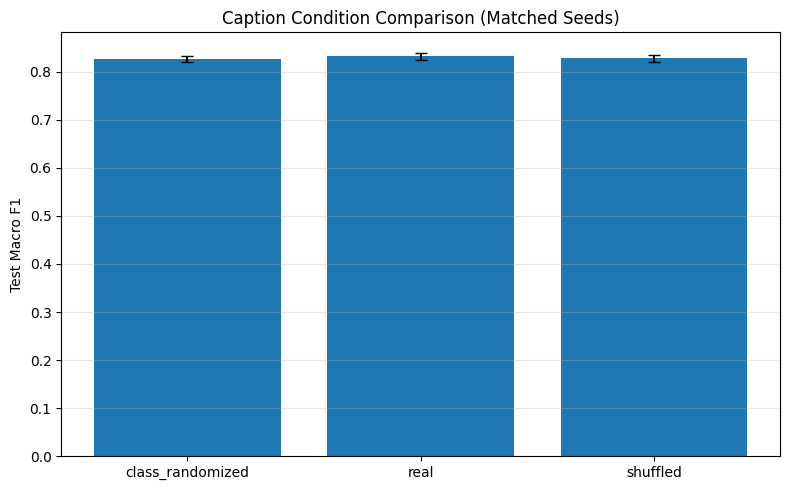

In [9]:
# ------------------------------------------------------------
# 4. plot
# ------------------------------------------------------------
plot_df = df_main.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x,
    plot_df["Test Macro F1 Mean"],
    yerr=plot_df["Test Macro F1 Std"],
    capsize=4,
)
plt.xticks(x, plot_df["Condition"])
plt.ylabel("Test Macro F1")
plt.title("Caption Condition Comparison (Matched Seeds)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



### Interpretation

Across the matched 30-seed runs, the `real` caption condition achieved the highest mean test macro-F1, followed by `shuffled`, then `class_randomized`.

For test macro-F1:

- `real`: `0.8325`
- `shuffled`: `0.8284`
- `class_randomized`: `0.8267`

The paired seed-by-seed comparisons show that `real` captions produced a **small but statistically reliable** improvement over both control conditions:

- `real - shuffled`: mean delta `+0.0041`, paired t-test `p = 0.0021`, Wilcoxon `p = 0.0028`
- `real - class_randomized`: mean delta `+0.0058`, paired t-test `p = 0.00028`, Wilcoxon `p = 0.00080`

This indicates that **correct image-caption alignment contributes useful information** in the current frozen-encoder fusion setup. However, the effect size is modest, so the result supports a **qualified** semantic-complementarity claim rather than a strong one.

A careful interpretation is therefore:

> Real captions provide a small but statistically significant benefit over shuffled and class-randomized caption controls, suggesting that correct image-caption pairing contributes useful information beyond a generic textual prior or regularization effect. At the same time, the gain is modest, indicating that the caption contribution is complementary rather than strongly dominant in the present frozen-encoder fusion model.

In [11]:
# ------------------------------------------------------------
# 6. Optional save
# ------------------------------------------------------------
analysis_dir = comparison_root / "caption_sanity_comparison"
analysis_dir.mkdir(parents=True, exist_ok=True)

df_main.to_csv(analysis_dir / "main_result_summary.csv", index=False)
df_paired.to_csv(analysis_dir / "paired_seed_comparisons.csv", index=False)
df_seed_level.to_csv(analysis_dir / "seed_level_test_macro_f1.csv", index=False)

print(f"\nSaved comparison tables to: {analysis_dir}")


Saved comparison tables to: /home/ding-zhang/Dongmei/DATA255/Project/experiments/caption_sanity_comparison
